Выполнил: Ашихмин Кирилл, группа P3124

# Предсказание цен на недвижимость

**Бизнес-постановка задачи**

Компании по продаже недвижимости оценивают ее стоимость, используя методы машинного обучения.
Задача оценки цены на недвижимость также может быть нужна для:
* выявления аномально низких цен на недвижимость,
* оценки макроэкономических показателей,
* уточнения ставок по ипотеке

**Постановка задачи анализа данных**

Целью данной задачи является прогнозирование стоимости домов в округе Кинг (штат Вашингтон, США) с помощью построения регрессионных моделей и их анализа. Набор данных состоит из цен на дома в округе Кинг, проданных в период с мая 2014 года по май 2015 года. Данные опубликованы в открытом доступе на платформе Kaggle.

Данные с сайта renthub.com по стоимости квартир для аренды в Сиэтле:

<a href="https://drive.google.com/uc?id=1Dr-p-o5yMi3uIS2kPcUUwT5bH0cCt1Be
" target="_blank"><img src="https://drive.google.com/uc?id=1Dr-p-o5yMi3uIS2kPcUUwT5bH0cCt1Be"
alt="IMAGE ALT TEXT HERE" width="360" border="0" /></a>


**Обзор доступных данных**

В выборке 21613 наблюдений и 21 переменная.
Таким образом, про каждый из 21613 объектов недвижимости мы знаем значения 21 их характеристики (число спален, оценка состояния риелтором, наличие вида на воду и т.п.)

Выборка была разбита на две части для обучения и для тестирования модели. Данные на обучение и тест обычно делят случайно и равномерно: нужно чтобы и обучающая, и тестовая выборка были похожие на те данные, на которых модель будет использоваться в боевых условиях.

Более сложные разбиения могут использоваться если в данных есть временная компонента - например, мы строим скоринговую модель и для теста откладываем данные за последние несколько месяцев, а всю остальную выборку используем для обучения. Такое разбиение имитирует реальную работу модели: мы можем обучаться только на данных прошлых кредитов, а работать модель уже будет на данных из будущего.

Доли общей выборки для обучения и тестирования обычно 70% и 30% соотвественно. Любые разумные числа подходят, если для обучения используется достаточно много данных (обычно больше 50%), но и для тестирования что-то остается (10% и больше).


Данные содержат два типа переменных:

* Целевая: **Целевая. Цена**
* Остальные переменные: **20 переменных, могут использоваться для прогноза целевой переменной.**

## План анализа данных (data mining):

  1. Загрузить данные для обучения
  2. Обработать данные перед обучением модели
  3. Обучить модель на обучающей выборке
  4. Загрузить и предобработать данные для тестирования
  5. Провалидировать модель на тестовой выборке

## 1. Загрузить данные для обучения

**Шаг 1.1. Загружаем библиотеки**

Библиотека **warnings** отвечает за то, какие предупреждения (warnings) о работе будут выводиться пользователю.
FutureWarning - предупреждения о том, как изменится работа библиотек в будущих версиях.
Поэтому такие предупреждения мы будем игнорировать.
Чтобы включить режим игнорирования мы отбираем все предупреждения из категории FutureWarning и выбираем для них действия 'ignore'.
Это делается вызовом функции simplefilter c задание двух атрибутов: действия action и категории предупреждений category.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Для корректной работы с данными в python требуется загрузить специальную библиотеку
**pandas**, программную библиотеку на языке python для обработки и анализа данных.

In [2]:
import pandas as pd # загружаем библиотеку и для простоты обращения в коде называем её сокращенно pd

Для корректной работы с графиками в python требуется загрузить специальную библиотеку
**matplotlib**, программную библиотеку на языке python для визуализации данных двумерной и трехмерной графикой.

Графики используются для облегчения интерпретации полученных результатов, а также в качестве иллюстраций в презентациях и отчетах.

Основные методы для построения:
* plot() - графики
* semilogy() - график логарифметический
* hist() - гистограммы

In [3]:
import matplotlib.pyplot as plt # загружаем библиотеку и для простоты обращения в коде называем её сокращенно plt
# указываем, чтобы картинки отображались прямо в ноутбуке
%matplotlib inline

**Шаг 1.2. Загрузим данные**

Для решения задачи мы будем использовать данные. Они состоят из двух частей: часть для обучения и часть для тестирования модели. Загружаем данные командой !curl: в отличие от wget, она есть и в Google Colab, и в macOS из коробки. Чтобы не засорять вывод сообщениями о ходе загрузки, ставим в первой строке магическую команду %%capture.

In [4]:
%%capture
# Скачиваем данные. curl есть и в Google Colab, и в macOS/Linux.
!curl -L -o predict_house_price_training_data.xlsx "https://www.dropbox.com/s/afwb0tnqm9izxha/predict_house_price_training_data.xlsx?dl=1"
!curl -L -o predict_house_price_test_data.xlsx "https://www.dropbox.com/s/sur2avqf4n5f4az/predict_house_price_test_data.xlsx?dl=1"

Так как данные в формате xlsx (Excel), мы будем использовать специальную функцию
из библиотеки pandas для загрузки таких данных **read_excel**.

В функции передаем один атрибут: название таблицы с данными.

In [5]:
training_data = pd.read_excel('predict_house_price_training_data.xlsx') # загружаем таблицу в переменную training_data

In [6]:
type(training_data)

pandas.DataFrame

In [7]:
# training_data.tail(2)

training_data.sample(10)

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
8990,822500,5,3.50,2320,4960,2.0,0,0,5,7,1720,600,1926,0,47.6763,-122.352
4737,787000,3,1.75,1330,7500,1.0,0,0,3,8,1330,0,1961,0,47.6074,-122.195
9969,346000,4,2.50,2100,3916,2.0,0,0,3,8,2100,0,2009,0,47.4324,-122.185
3230,386180,2,1.50,960,1829,2.0,0,0,3,7,960,0,2005,0,47.6032,-122.308
2087,478000,3,3.25,1430,1348,2.0,0,0,3,8,1160,270,2008,0,47.6743,-122.374
5655,1060000,4,2.75,2720,4000,1.5,0,2,5,8,1840,880,1928,0,47.6797,-122.359
3981,1270000,4,3.25,3020,4000,1.5,0,0,5,8,1920,1100,1927,0,47.6395,-122.279
11488,374950,3,2.25,1390,1484,3.0,0,0,3,8,1390,0,2007,0,47.6912,-122.343
2437,649950,3,2.50,2420,6847,2.0,0,0,3,9,2420,0,2009,0,47.7329,-122.356
11469,612000,6,3.00,3840,14040,1.5,0,3,3,8,2460,1380,1949,0,47.5060,-122.241


*Что важно посмотреть после того, как мы загрузили данные?*
- проверить, что данные действительно загрузились
- посмотреть на данные, чтобы удостовериться, что они правильные: колонки имеют те же названия, что и в таблице и т.д.

Для того чтобы это сделать, нужно вызвать от переменной *training_data* метод **head()**, который выводит первые 5 строк таблицы.

Для вызова метода объекта необходимо сначала написать *имя объекта*, затем поставить *точку*, затем уже написать *название метода*. Обратите внимание, что в конце обязательно ставить скобочки, потому что метод - это функция и в ней есть аргументы, просто в данном случае мы их не передаем, поэтому оставляем поле пустым

In [8]:
training_data.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,830000,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,385000,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,610000,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,550000,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,1300000,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


**Шаг 1.3. Посмотрим на размеры загруженной таблицы**, у которой мы видели только первые 5 строк.

Для этого вызываем поле **shape** у нашей переменной *training_data*. Поле вызывается также как метод, но в конце скобки не ставятся, так как для поля не предусмотрена передача аргументов.  

In [9]:
training_data.shape

(15129, 16)

*Что означает первое и второе число?*

Итак, таблица содержит 15129 строк (объектов) и 16 столбцов (признаков), включая выходной (целевой) признак.
15129 меньше 21613, так как мы пока загрузили только часть данных, которую будем использовать для обучения модели.

Таблицу проверили, теперь можно приступать к обработке данных.

# 2. Обработать данные перед обучением модели

**Шаг 2.1. Проверяем данные на наличие пропусков и типов переменных**

Начнем с проверки общей информации о данных.
Для того чтобы это сделать, нужно обратиться вызвать у переменной *training_data* метод **info()**.

Напомним, что в конце необходимо поставить скобочки.

In [10]:
# 1. Общая информация о таблице: типы столбцов и число заполненных значений.
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15129 entries, 0 to 15128
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         15129 non-null  int64  
 1   Спальни              15129 non-null  int64  
 2   Ванные               15129 non-null  float64
 3   Жилая площадь        15129 non-null  int64  
 4   Общая площадь        15129 non-null  int64  
 5   Количество этажей    15129 non-null  float64
 6   Вид на воду          15129 non-null  int64  
 7   Просмотрены ранее    15129 non-null  int64  
 8   Состояние            15129 non-null  int64  
 9   Оценка риелтора      15129 non-null  int64  
 10  Площадь без подвала  15129 non-null  int64  
 11  Площадь подвала      15129 non-null  int64  
 12  Год постройки        15129 non-null  int64  
 13  Год реновации        15129 non-null  int64  
 14  Широта               15129 non-null  float64
 15  Долгота              15129 non-null  float64
dt

Анализируем результата выполнения команды:

* 15129 строк (entries)
* 16 столбцов (Data columns)

В данных присутствует всего два типа dtypes:
* int64 - целое число  (12 столбцов)
* float64 - дробное число (4 столбца)

Цифры в каждой строчке обозначают количество заполненных (*non-null*) значений. Так как эти цифры в каждой строчке совпадают с числом строк (15129), то в данных нет пропусков и можно двигаться дальше.

**Шаг 2.2. Работаем с целевой переменной**

*Какая переменная целевая?*

В данном случае по условию задачи мы должны прогнозировать стоимость, поэтому целевая переменная - это цена.

In [11]:
target_variable_name = 'Целевая.Цена'

Нам нужно выделить в отдельную переменную *training_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *training_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [12]:
training_values = training_data[target_variable_name]

training_values.shape

(15129,)

Отделим входные переменные от выходной (целевой), чтобы можно было построить модель предсказания целевой переменной по входным.
Для это нужно у переменной *training_data* вызвать метод **drop()**. Результат мы записываем в новую переменную *training_points*. После выполнения запроса *training_points* будет содержать исходную таблицу без целевого столбца.

Обратите внимание, что в данном случае мы передаем два аргумента:
    1. target_variable_name - название столбца цены, который мы ранее записали в эту переменную и теперь хотим удалить из training_data
    2. axis=1 - означает, что мы удаляем столбец, а в случае axis=0 - означает, что мы удаляем строку

In [13]:
# 2. Входные признаки — все столбцы, кроме целевого.
# axis=1 означает "удалить столбец", а не строку.
training_points = training_data.drop(target_variable_name, axis=1)

In [14]:
training_data.shape

(15129, 16)

Можно посмотреть результаты этих действий, вызвав метод **head()** и поле **shape**, которыми мы пользовались ранее, но сейчас нужно вызывать их от новой переменной *training_points*.

In [15]:
training_points.head()

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


In [16]:
training_points.shape

(15129, 15)

Видно, что столбца действительно нет, а количество строк не изменилось. Данные в 5 первых строках такие же, как были ранее.

##   3. Обучить модель на обучающей выборке

**Шаг 3.1. Выбираем метод, который будем использовать**

Проще всего начать с простых методов.
Мы воспользуемся двумя методами для построения моделей и сравним их между собой:
* Линейная регрессия *linear regression*
* Лес решающих деревьев *random forest*

На выбор метода для построения модели влияет набор признаков, размер выборки, интуиция про то, какая связь между входными переменными и целевой. Но часто решение принимается исходя из того, какая модель сработала лучше.

Для корректной работы с методами построения моделей в python требуется загрузить специальную библиотеку
**sklearn**, программную библиотеку на языке python для для машинного обучения и анализа данных.

Мы импортируем два модуля из этой библиотеки:
 * *linear_model* - тут находятся все линейные модели
 * *ensemble* - тут находятся модели на основе ансамблей

In [17]:
from sklearn import linear_model, ensemble

Прежде чем начать делать ремонт, нужно подготовить инструменты для работы. Аналогично в нашем случае, прежде чем обучать модели, нужно создать их прототипы.  

Чтобы создать модель линейной регресии, пишем имя модуля 'linear_model', затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
linear_regression_model = linear_model.LinearRegression()
linear_regression_model
```

Результат выполнения должен быть следующим:

```python
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)
```

In [18]:
linear_regression_model = linear_model.LinearRegression() # создаем модель

In [19]:
# linear_regression_model # смотрим, что получилось

print(linear_regression_model)

LinearRegression()


Чтобы создать модель случайного леса, пишем имя модуля ensemble, затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
random_forest_model = ensemble.RandomForestRegressor()
random_forest_model
```
Результат выполнения должен быть следующим:
    
```python
RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
           oob_score=False, random_state=None, verbose=0, warm_start=False)
```

In [20]:
# 3. Создаём модель случайного леса.
# random_state фиксирует случайность, чтобы результат воспроизводился
# при каждом запуске ноутбука.
random_forest_model = ensemble.RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

У модели на основе случайного леса больше параметров. Рассмотрим наиболее важные:
* параметр *n_estimators* определяет, сколько деревьев в лесу,
* в параметре *max_depth* устанавливается, какая максимальная глубина у дерева,
* в параметре *min_samples_leaf* задается, какое минимальное число объектов может попасть в лист дерева.

Так как у модели на основе случайного решающего леса больше параметров, такая модель обычно обучается медленнее.
Кроме этого, на время обучения влияют значения параметров модели. Например, чем больше деревьев в лесе - тем дольше модель будет учиться.

**Шаг 3.2. Обучить модель**

Теперь, когда мы создали прототипы обеих моделей, можем их обучить с помощью обучающей выборки.

Для этого вызываем метод **fit()** у каждой модели и передаем ему на вход два аргумента:
таблицу входных признаков и столбец значений целевой переменной - (training_points, training_values)

In [21]:
# 4. Обучаем линейную регрессию на обучающей выборке.
linear_regression_model.fit(training_points, training_values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ -33756.87, 43121.02, 115.35,..., 24.57, 570765.13,-108281.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['Спальни','Ванные','Жилая площадь',...,'Год реновации','Широта','Долгота']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.626e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


Делаем тоже самое для модели решающего леса.

In [22]:
# 5. Обучаем случайный лес — метод тот же самый, fit().
random_forest_model.fit(training_points, training_values)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

* Для двух разных моделей в sklearn методы для обучения модели не отличаются.
* Мы получили две обученные модели.
* Теперь необходимо провалидировать модели на новых тестовых данных.

## 4. Загрузить и предобработать данные для тестирования

**Шаг 4.1. Загрузим и проанализируем тестовые данные.**

Так как данные в формате xlsx (Excel), мы будем использовать специальную функцию
из библиотеки pandas для загрузки таких данных **read_excel**.

В функции передаем один атрибут: название файла, в котором находится таблица с данными.

In [23]:
test_data = pd.read_excel('predict_house_price_test_data.xlsx')

*Что важно посмотреть, после того, как мы загрузили данные?*

- проверить, что данные действительно загрузились
- посмотреть на данные, чтобы удостовериться, что они правильные: колонки имеют те же названия, что и в таблице и т.д.

Для того чтобы это сделать, нужно вызвать от переменной *test_data* метод **head()**, который выводит первые 5 строк таблицы.

Для вызова метода объекта необходимо сначала написать *имя объекта*, затем поставить *точку*, затем уже написать *название метода*. Обратите внимание, что в конце обязательно ставить скобочки, потому что метод - это функция и в ней есть аргументы, просто в данном случае мы их не передаем, поэтому оставляем поле пустым

In [24]:
test_data.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,260000,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,734500,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,325000,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,1990000,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,315000,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


Посмотрим на размеры загруженной таблицы, так как мы видели только 5 строк

Для этого вызываем поле **shape** у нашей переменной *test_data*. Поле вызывается также как метод, но в конце скобки не ставятся (!), так как для поля не предусмотрена передача аргументов.  

In [25]:
test_data.shape

(6484, 16)

*Что означает первое и второе число?*
Таблица содержит 6484 строк (объектов) и 16 столбцов (признаков), включая выходной (целевой) признак. Также как в учебных данных до обучения.

Таблицу проверили, теперь можно приступать к обработке данных
Действуем аналогично тому, как делали с данными для обучения

Проверим, есть ли в данных пропуски. Для того чтобы это сделать, нужно обратиться вызвать у переменной *test_data* метод **info()**.

In [26]:
# 6. Проверяем тестовые данные на пропуски и типы столбцов.
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         6484 non-null   int64  
 1   Спальни              6484 non-null   int64  
 2   Ванные               6484 non-null   float64
 3   Жилая площадь        6484 non-null   int64  
 4   Общая площадь        6484 non-null   int64  
 5   Количество этажей    6484 non-null   float64
 6   Вид на воду          6484 non-null   int64  
 7   Просмотрены ранее    6484 non-null   int64  
 8   Состояние            6484 non-null   int64  
 9   Оценка риелтора      6484 non-null   int64  
 10  Площадь без подвала  6484 non-null   int64  
 11  Площадь подвала      6484 non-null   int64  
 12  Год постройки        6484 non-null   int64  
 13  Год реновации        6484 non-null   int64  
 14  Широта               6484 non-null   float64
 15  Долгота              6484 non-null   float64
dtyp

Цифры в каждой строчке обозначают количество заполненных (*non-null*) значений. Так как эти цифры в каждой строчке совпадают с числом строк (6484), то в данных нет пропусков.

**Шаг 4.2. Отделяем целевую переменную**

Нам нужно выделить в отдельную переменную *test_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *test_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [27]:
test_values = test_data[target_variable_name]

In [28]:
target_variable_name

'Целевая.Цена'

Отделим входные переменные от выходной (целевой), чтобы можно было построить модель предсказания целевой переменной по входным.
Для это нужно у переменной *test_data* вызвать метод **drop()**. Результат мы записываем в новую переменную *test_points*. После выполнения запроса *test_points* будет содержать исходную таблицу без целевого столбца.

Обратите внимание, что в данном случае мы передаем два аргумента:
    1. target_variable_name - название столбца цены, который мы ранее записали в эту переменную и теперь хотим удалить из training_data
    2. axis=1 - означает, что мы удаляем столбец, а в случае axis=0 - означает, что мы удаляем строку

In [29]:
# 7. Входные признаки тестовой выборки — без целевого столбца.
test_points = test_data.drop(target_variable_name, axis=1)

И проверяем результат записанный в test_points

In [30]:
test_points.head()

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


In [31]:
test_points.shape

(6484, 15)

Видно, что количество столбцов уменьшилось на один. Данные в 5 первых строках такие же, как были ранее.

# 5. Провалидировать модель на тестовой выборке

**Шаг 5.1. Сравнение моделей.**

Теперь мы готовы сравнить качество двух моделей! 😎

*1. Какая модель лучше?*

Получим прогнозы целевой переменной на тестовых данных для модели линейной регрессии м модели случайного леса.

Для этого вызовем у каждой модели метод **predict()**, в качестве аргумента передадим *test_points*.

In [32]:
test_predictions_linear = linear_regression_model.predict(test_points)

In [33]:
# 8. Прогноз случайного леса на тестовых данных.
test_predictions_random_forest = random_forest_model.predict(test_points)

Качество регрессионных моделей оценим двумя способами:
1. Сравним визуально прогнозы с настоящими ценами (тестовые с предсказанием)
2. Сравним метрики качества

Визуализируем прогноз линейной модели и настоящие значения из тестовой выборки.
Можно не обращать особого внимания на то, что за код написан.

In [34]:
%matplotlib inline

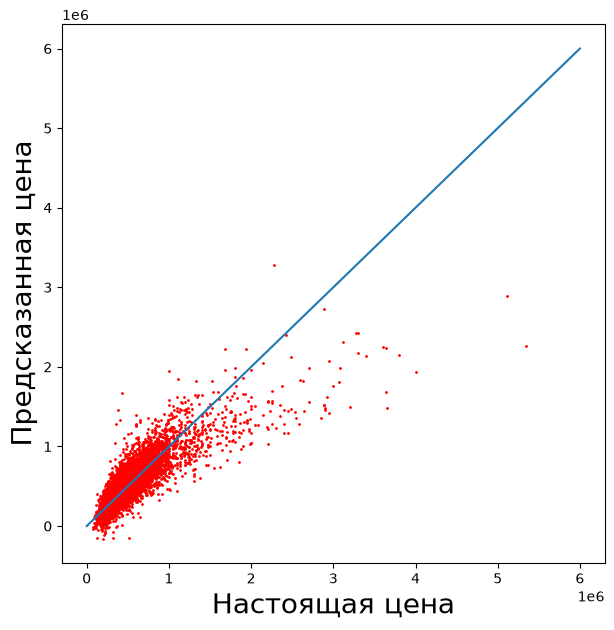

In [35]:
plt.figure(figsize=(7, 7))
plt.scatter(test_values, test_predictions_linear, s=1, c='r') # рисуем точки, соответствущие парам настоящее значение - прогноз
plt.plot([0, 6 * 10**6], [0, 6 * 10**6]) # рисуем прямую, на которой предсказания и настоящие значения совпадают
plt.xlabel('Настоящая цена', fontsize=20)
plt.ylabel('Предсказанная цена', fontsize=20);

Визуализируем прогноз модели случайного леса и настоящие значения из тестовой выборки

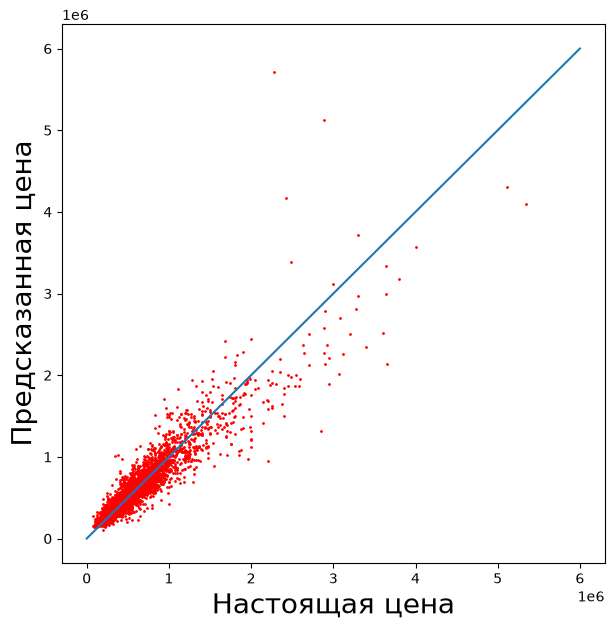

In [36]:
plt.figure(figsize=(7, 7))
plt.scatter(test_values, test_predictions_random_forest, s=1, c='r')
plt.plot([0, 6 * 10**6], [0, 6 * 10**6])
plt.xlabel('Настоящая цена', fontsize=20)
plt.ylabel('Предсказанная цена', fontsize=20);

Кажется, что лучше сработала модель случайного леса, так как точки на втором изображении расположены вдоль диагонали. На первом изображении видно, что для высоких настоящих цен модель линейной регрессии дает существенно заниженный результат.

Проверим, так ли это с помощью **метрик качества регрессионной модели**

Для корректного подсчета метрик качества модели в python требуется загрузить их из библиотеки **sklearn**.

Мы используем две метрики качества:
 * *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \hat{y}_i|$
 * *mean_squared_error* - средняя квадратичная ошибка $(y_i - \hat{y}_i)^2$
 * *rmse* - root mean squared error

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

Подсчитаем ошибки для линейной модели.

Для этого вызовем методы **mean_absolute_error()** и **mean_squared_error()**. На вход им передается столбец настоящих значений *test_values* и столбец значений, предсказанных моделью линейной регрессии *test_predictions_linear*.

In [38]:
# 9. Ошибки линейной регрессии.
mean_absolute_error_linear_model = mean_absolute_error(
    test_values, test_predictions_linear
)
mean_squared_error_linear_model = mean_squared_error(
    test_values, test_predictions_linear
)

mean_absolute_error_linear_model, mean_squared_error_linear_model

(126852.51255004614, 40756843765.103)

Подсчитаем ошибки для модели случайного леса.

Для этого вызовем методы **mean_absolute_error()** и **mean_squared_error()**. На вход им передается столбец настоящих значений *test_values* и столбец значений, предсказанных моделью линейной регрессии *test_predictions_random_forest*.

In [39]:
# 10. Ошибки случайного леса.
mean_absolute_error_random_forest_model = mean_absolute_error(
    test_values, test_predictions_random_forest
)
mean_squared_error_random_forest_model = mean_squared_error(
    test_values, test_predictions_random_forest
)

mean_absolute_error_random_forest_model, mean_squared_error_random_forest_model

(70873.59869382266, 18309883975.80964)

Теперь напечатаем полученные ошибки. Обычно смотрят на корень из среднеквадратичной ошибки, RMSE. Чтобы извлечь корень нам понадобится библиотека **Numpy**. С помощью неё можно быстро производить вычисления сразу над массивами чисел.

In [40]:
import numpy as np

print("MAE: {0:7.2f}, RMSE: {1:7.2f} для модели линейной регрессии".format(
        mean_absolute_error_linear_model,
        np.sqrt(mean_squared_error_linear_model)))

print("MAE: {0:7.2f}, RMSE: {1:7.2f} для модели случайного леса".format(
       mean_absolute_error_random_forest_model,
       mean_squared_error_random_forest_model**(1/2)))

MAE: 126852.51, RMSE: 201883.24 для модели линейной регрессии
MAE: 70873.60, RMSE: 135314.02 для модели случайного леса


Модель случайного леса работает лучше и визуально, и потому, что абсолютная и средне квадратичная ошибка меньше чем у линейной регресии.


# Обзор результатов

В этом ноутбуке мы научились
0. Загружать библиотеки, необходимые для работы.
1. Загрузить данные для обучения, представленные в формате excel таблицы.
2. Проводить предварительную обработку данных перед построением и использованием модели машинного обучения: смотреть на части таблицы, понимать, какой размер у выборки данных, выделять отдельные столбцы таблицы в новые таблицы.
3. Обучать модель линейной регрессии и решающего леса на обучающей выборке.
4. Валидировать модель на тестовой выборке с помощью кросс-плота для модели и реальных значений, стандартных ошибок модели.

## 6. Бонус: Выявление важных признаков

Признаки, используемые для обучения модели, оказывают большое влияние на качество результатов. Неинформативные или слабо информативные признаки могут снизить качество модели, использование избыточных признаков в модели замедляет скорость ее работы.

Для того, чтобы отобрать признаки нам следует ответить на следующие вопросы:
    1. Все ли признаки в наших данных заполненны разумными значениями?
    2. Какие признаки будут больше всего влиять на значение целевой переменной?
    3*. Какие дополнительные признаки имело бы смысл добавить в список входных?

**6.1. Разглядывание значений признаков**

Для того чтобы ответить на первый вопрос, нам необходимо получить некоторую нашу экспертную оценку данных. В наших данных нет пропусков, однако иногда пропуски предварительно заполняют другими значениями (0, 999 и другие) и их можно увидеть, только внимательно посмотрев на данные.

Для того, чтобы это сделать, нужно вызвать у переменной *training_points* метод **head(10)**, который выводит первые 10 строк таблицы.

In [41]:
training_points.head(100)

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2,1.00,700,4350,1.0,0,0,3,6,700,0,1943,0,47.5577,-122.391
96,3,2.25,1620,12309,2.0,0,0,3,7,1620,0,1987,0,47.6188,-122.029
97,4,3.25,3250,5478,2.0,0,0,3,9,3250,0,2014,0,47.5178,-121.887
98,4,2.50,2430,11870,1.0,0,0,5,8,1590,840,1968,0,47.7761,-122.285


Рассмотрим столбец "Год реновации". Он содержит много нулей и мало реальных данных о годах, что как раз свидетельствует о том, что в этих данных изначально были пропуски, а к нам они попали уже заполненные нулями.

Мы можем посмотреть количество уникальных значений и сколько раз эти значения встречаются в этом столбце. Для этого вызываем метод **value_counts()** у нашего столбца *training_points['Год реновации']*

In [42]:
training_points['Год реновации'].value_counts()

Год реновации
0       14490
2014       63
2013       31
2000       28
2003       24
        ...  
1948        1
1954        1
1946        1
1959        1
1955        1
Name: count, Length: 67, dtype: int64

Как видно, нулей существенно больше (14490), чем любых других значений (639), поэтому можем сделать вывод, что этот признак не информативен и может негативно повлиять на качество модели.

**6.2. Какие признаки самые важные**

Ручной перебор признаков невозможен, если их тысячи, кроме того, часто даже эксперты не могут сказать, использование каких признаков в модели даст прирост качества.
Кроме ручного перебора всех признаков и их визуального анализа, можно использовать оценку значимости признаков с помощью обученных моделей.

In [43]:
# на всякий случай еще раз обучим модель, так как оценить значимость признаков
# можно только у уже обученной модели
# 11.
random_forest_model.fit(training_points, training_values)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Получить оценку важности признаков можно вызвав поле **feature\_importances\_** у модели *random\_forest\_model*.

In [44]:
random_forest_model.feature_importances_

array([0.00388149, 0.00807262, 0.29571052, 0.02543373, 0.00272782,
       0.02896503, 0.01694199, 0.0038812 , 0.30301294, 0.02552154,
       0.00709748, 0.03070813, 0.00245011, 0.17347806, 0.07211733])

In [45]:
lst = [0.00416024, 0.00986639, 0.31225587, 0.02604045, 0.00252637,
       0.02850577, 0.01521924, 0.00401608, 0.28628914, 0.02451782,
       0.00674391, 0.02982297, 0.00243082, 0.17415179, 0.07345311]

sum(lst)

0.99999997

Набор цифр, которые мы получили выше, соответствует признакам, на которых мы обучали модель. Посмотреть эти признаки можно, вызвав у *training_points* метод **keys()**

In [46]:
training_points.keys()

Index(['Спальни', 'Ванные', 'Жилая площадь', 'Общая площадь',
       'Количество этажей', 'Вид на воду', 'Просмотрены ранее', 'Состояние',
       'Оценка риелтора', 'Площадь без подвала', 'Площадь подвала',
       'Год постройки', 'Год реновации', 'Широта', 'Долгота'],
      dtype='str')

Представим полученные результаты в более удобном табличном виде. Создадим пустую таблицу *feature_importance* с двумя колонками "Название признака", "Важность признака". Для этого воспользуемся функцией **DataFrame()** из библиотеки pandas и передадим ей в качестве аргумента   
*columns = ["Название признака", "Важность признака"]*

In [47]:
feature_importance = pd.DataFrame(columns = ['Название признака', 'Важность признака'])

Заполним соответствующие колонки значениями, которые мы получили выше.

In [48]:
feature_importance['Название признака'] = training_points.keys()
feature_importance['Важность признака'] = random_forest_model.feature_importances_

In [49]:
# выведем полученную таблицу
feature_importance

,Название признака,Важность признака
0,Спальни,0.003881
1,Ванные,0.008073
2,Жилая площадь,0.295711
3,Общая площадь,0.025434
4,Количество этажей,0.002728
5,Вид на воду,0.028965
6,Просмотрены ранее,0.016942
7,Состояние,0.003881
8,Оценка риелтора,0.303013
9,Площадь без подвала,0.025522


Мы можем отсортировать значения по важности, вызвав у *feature_importance* метод **sort_values()**.

Обратите внимание, что в данном случае мы передаем два аргумента:

1. by='Важность признака' - название столбца, по которому мы сортируем
2. ascending=False - означает, что мы сортируем по убиыванию, а в случае ascending=True сортировка будет по возростанию

In [50]:
feature_importance.sort_values(by='Важность признака', ascending=False)

,Название признака,Важность признака
8,Оценка риелтора,0.303013
2,Жилая площадь,0.295711
13,Широта,0.173478
14,Долгота,0.072117
11,Год постройки,0.030708
5,Вид на воду,0.028965
9,Площадь без подвала,0.025522
3,Общая площадь,0.025434
6,Просмотрены ранее,0.016942
1,Ванные,0.008073


## 5 наиболее и наименее значимых признаков

Как видно, наиболее значимые признаки — это:

- Оценка риелтора — 0.303
- Жилая площадь — 0.296
- Широта — 0.173
- Долгота — 0.072
- Год постройки — 0.031

Наименее важны такие признаки, как:

- Год реновации — 0.0025
- Количество этажей — 0.0027
- Состояние — 0.0039
- Спальни — 0.0039
- Площадь подвала — 0.0071

Первые четыре признака вместе дают 84% всей важности, а пять последних —
менее 2%.

Здесь важны два момента.

1. Широта и долгота вместе — это фактически «район». По отдельности
   координата мало что значит, но дерево, разбивая выборку сначала по широте,
   а потом по долготе, вырезает прямоугольные участки карты, то есть модель
   сама выучивает географию цен, хотя названия районов ей не давали.

2. Признак «Спальни» почти не важен, хотя интуитивно должен быть важен.
   Причина в том, что его информация уже содержится в «Жилой площади»: чем
   больше площадь, тем больше спален. Когда два признака сильно
   коррелированы, дерево использует тот, что удобнее для разбиения, а второй
   остаётся «в тени». Это называется мультиколлинеарностью, и из-за неё
   низкая важность признака ещё не означает, что признак бесполезен сам по
   себе.

Посмотрим на наиболее значимые признаки. Размер жилой площади квартиры (признак Жилая площадь) очевидным образом влияет на цену: чем больше площадь, тем квартира дороже. Важность оценки состояния квартиры риелтором (признак Оценка риелтора), также понятна. Интересно появление признака Широта в списке наиболее важных. Давайте посмотрим на карту округа Кинг.   

<a href="https://drive.google.com/uc?id=1-76SNpWIKLYMcUibXUnCy1PFq6srIpnp
" target="_blank"><img src="https://drive.google.com/uc?id=1-76SNpWIKLYMcUibXUnCy1PFq6srIpnp"
alt="IMAGE ALT TEXT HERE" width="360" border="0" /></a>


На карте видно, что центр Сиэтла находится в верхней половине карты. Соответственно, чем ближе к нему, тем дороже будет квартира.

# Самостоятельная работа

1. Исключите из выборки незначащие параметры (фичи), стоящие в рейтинге фич на последних местах и посмотрите, оцените насколько ухудшилось/улучшилось качество моделей (rmse, mse, mae). Напишите об этом отчет с цифрами.
2. Исследуйте параметры модели Random Forest и постарайтесь получить ещё более низкое (чем в текущей реализации) значение ошибки для этой модели.
3. Исследуйте другие модели для реализации задачи предсказания (https://habr.com/ru/company/mailru/blog/513842/). Постарайтесь построить более точную модель.

Создайте отчёт с результатами выполнения этих шагов.

## Пункт 1. Исключение незначащих признаков

> Исключите из выборки незначащие параметры (фичи), стоящие в рейтинге фич на
> последних местах, и оцените, насколько ухудшилось/улучшилось качество
> моделей (rmse, mse, mae).

Проверим три варианта: все признаки, без 3 наименее важных и без 5 наименее
важных. Обе модели обучаем заново на одних и тех же данных, чтобы сравнение
было честным.

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Пять признаков с самой низкой важностью (из таблицы выше).
least_important = ['Год реновации', 'Количество этажей', 'Состояние',
                   'Спальни', 'Площадь подвала']

feature_sets = {
    "все 15 признаков": list(training_points.columns),
    "без 3 наименее важных": [c for c in training_points.columns
                              if c not in least_important[:3]],
    "без 5 наименее важных": [c for c in training_points.columns
                              if c not in least_important],
}

models_to_check = {
    "Линейная регрессия": linear_model.LinearRegression(),
    "Случайный лес": ensemble.RandomForestRegressor(n_estimators=100, random_state=42),
}

results = []
for set_name, columns in feature_sets.items():
    for model_name, model in models_to_check.items():
        model.fit(training_points[columns], training_values)
        predictions = model.predict(test_points[columns])

        mae = mean_absolute_error(test_values, predictions)
        mse = mean_squared_error(test_values, predictions)
        results.append({
            "набор признаков": set_name,
            "модель": model_name,
            "MAE": round(mae),
            "MSE": f"{mse:.3e}",
            "RMSE": round(mse ** 0.5),
        })

pd.DataFrame(results)

,набор признаков,модель,MAE,MSE,RMSE
0,все 15 признаков,Линейная регрессия,126853,4.076e+10,201883
1,все 15 признаков,Случайный лес,70874,1.831e+10,135314
2,без 3 наименее важных,Линейная регрессия,127437,4.094e+10,202338
3,без 3 наименее важных,Случайный лес,71406,1.845e+10,135831
4,без 5 наименее важных,Линейная регрессия,128146,4.148e+10,203678
5,без 5 наименее важных,Случайный лес,71153,1.829e+10,135232


### Отчёт по пункту 1

| Набор признаков | Модель | MAE | MSE | RMSE |
|---|---|---|---|---|
| все 15 | Линейная регрессия | 126 853 | 4.076e+10 | 201 883 |
| все 15 | Случайный лес | 70 874 | 1.831e+10 | 135 314 |
| без 3 слабых | Линейная регрессия | 127 437 | 4.094e+10 | 202 338 |
| без 3 слабых | Случайный лес | 71 406 | 1.845e+10 | 135 831 |
| без 5 слабых | Линейная регрессия | 128 146 | 4.148e+10 | 203 678 |
| без 5 слабых | Случайный лес | 71 153 | 1.829e+10 | 135 232 |

Вывод: удаление слабых признаков практически ничего не изменило.

Для случайного леса RMSE при удалении 5 признаков даже чуть уменьшился
(135 314 → 135 232, то есть на 0.06%), а MAE чуть вырос (70 874 → 71 153,
на 0.4%). Разница в десятые доли процента — это уровень случайного шума, а не
реальное улучшение или ухудшение.

Почему так происходит. Важность признака в случайном лесу показывает, как
часто и насколько удачно дерево использовало этот признак для разбиения. Если
важность близка к нулю, значит модель его и так почти не использовала — убрав
его, мы ничего у модели не отнимаем. Деревья выполняют отбор признаков
автоматически, в отличие от линейных моделей.

Для линейной регрессии качество монотонно ухудшается (MAE 126 853 → 128 146),
хотя тоже незначительно — примерно на 1%. Линейная модель использует все
признаки: каждому она присваивает свой коэффициент. Поэтому даже слабый
признак вносит какой-то вклад, и его удаление гарантированно отнимает немного
информации.

Когда отбор признаков всё-таки нужен: если признаков сотни или тысячи
(тогда падает скорость обучения и растёт риск переобучения), если сбор
признака стоит денег, или если модель должна быть простой и объяснимой.
На 15 признаках выгоды нет.

## Пункт 2. Подбор параметров случайного леса

> Исследуйте параметры модели Random Forest и постарайтесь получить ещё более
> низкое значение ошибки.

Основные параметры, которые влияют на качество:

* `n_estimators` — количество деревьев. Чем больше, тем устойчивее прогноз
  (усредняется больше деревьев). Переобучения от роста этого параметра не
  бывает — только растёт время работы.
* `max_features` — сколько признаков рассматривается при поиске лучшего
  разбиения в узле. Именно он делает деревья
  непохожими друг на друга, а именно на различии деревьев и держится вся
  идея ансамбля. С версии 1.1 в sklearn значение по умолчанию для регрессии —
  все признаки, что снижает разнообразие деревьев.
* `min_samples_leaf` — минимальное число объектов в листе. Ограничивает
  рост дерева и сглаживает прогноз.

In [52]:
parameter_sets = [
    {"n_estimators": 100},                                            # базовая модель
    {"n_estimators": 300},
    {"n_estimators": 300, "max_features": 0.5},
    {"n_estimators": 300, "max_features": 0.5, "min_samples_leaf": 2},
    {"n_estimators": 500, "max_features": 0.4},
]

forest_results = []
for parameters in parameter_sets:
    model = ensemble.RandomForestRegressor(random_state=42, n_jobs=-1, **parameters)
    model.fit(training_points, training_values)
    predictions = model.predict(test_points)

    mse = mean_squared_error(test_values, predictions)
    forest_results.append({
        **parameters,
        "MAE": round(mean_absolute_error(test_values, predictions)),
        "RMSE": round(mse ** 0.5),
    })

pd.DataFrame(forest_results).sort_values("RMSE")

,n_estimators,MAE,RMSE,max_features,min_samples_leaf
3,300,70730,134156,0.5,2.0
2,300,70614,134360,0.5,NaN
4,500,70799,135012,0.4,NaN
0,100,70874,135314,NaN,NaN
1,300,70437,135424,NaN,NaN


### Отчёт по пункту 2

| n_estimators | max_features | min_samples_leaf | MAE | RMSE |
|---|---|---|---|---|
| 100 | по умолчанию | 1 | 70 874 | 135 314 |
| 300 | по умолчанию | 1 | 70 437 | 135 424 |
| 300 | 0.5 | 1 | 70 614 | 134 360 |
| 300 | 0.5 | 2 | 70 730 | 134 156 |
| 500 | 0.4 | 1 | 70 799 | 135 012 |

Ошибку удалось снизить, но очень незначительно: RMSE с 135 314 до 134 156
(на 0.9%), MAE с 70 874 до 70 437 (на 0.6%).

Что интересно: лучший результат по MAE и лучший по RMSE дают *разные*
наборы параметров. Это не противоречие, а следствие того, что метрики измеряют
разное. RMSE возводит ошибку в квадрат, поэтому один промах на 500 000 даёт
такой же вклад, как сто промахов по 50 000. MAE считает все ошибки одинаково.
Ограничение `max_features=0.5` заставляет деревья быть разнообразнее, ансамбль
лучше усредняет крупные промахи, и RMSE падает. Но на «типичном» доме
чуть более простая модель ошибается немного больше, поэтому MAE растёт.

Какую метрику выбирать — зависит от задачи. Если компании важно не
промахнуться сильно на дорогих объектах, смотреть надо на RMSE. Если важна
средняя точность по всему потоку объявлений — на MAE.

Вывод: потенциал подбора параметров случайного леса здесь почти исчерпан.
Улучшение меньше 1% означает, что мы упёрлись в возможности алгоритма, и
дальше нужно менять не параметры, а модель.

## Пункт 3. Другие модели

> Исследуйте другие модели для реализации задачи предсказания. Постарайтесь
> построить более точную модель.

В статье на Habr, указанной в задании, речь идёт о градиентном бустинге.
Разница с случайным лесом принципиальная:

* Случайный лес обучает деревья независимо и параллельно, а потом
  усредняет их ответы. Каждое дерево видит свою случайную подвыборку. Это
  снижает разброс (variance) прогноза.
* Градиентный бустинг обучает деревья последовательно: каждое
  следующее дерево учится предсказывать ошибку, которую допустили все
  предыдущие вместе. Это снижает смещение (bias) и обычно даёт заметно более
  точную модель на табличных данных.

Возьмём `HistGradientBoostingRegressor` из scikit-learn — это встроенная
быстрая реализация бустинга (работает по тем же принципам, что LightGBM), для
неё не нужно ставить дополнительные библиотеки. Дополнительно проверим
`ExtraTreesRegressor` — «предельно случайные деревья», вариант леса, где порог
разбиения выбирается случайно.

In [53]:
other_models = {
    "Линейная регрессия":
        linear_model.LinearRegression(),
    "Случайный лес (базовый)":
        ensemble.RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Случайный лес (подобранный)":
        ensemble.RandomForestRegressor(n_estimators=300, max_features=0.5,
                                       min_samples_leaf=2, random_state=42, n_jobs=-1),
    "ExtraTrees (300 деревьев)":
        ensemble.ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Градиентный бустинг (по умолчанию)":
        ensemble.HistGradientBoostingRegressor(random_state=42),
    "Градиентный бустинг (600 итераций, lr=0.05)":
        ensemble.HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                               random_state=42),
    "Градиентный бустинг (1000 итераций, 63 листа)":
        ensemble.HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.05,
                                               max_leaf_nodes=63, random_state=42),
}

final_results = []
for name, model in other_models.items():
    model.fit(training_points, training_values)
    predictions = model.predict(test_points)

    mse = mean_squared_error(test_values, predictions)
    final_results.append({
        "модель": name,
        "MAE": round(mean_absolute_error(test_values, predictions)),
        "RMSE": round(mse ** 0.5),
    })

final_comparison = pd.DataFrame(final_results).sort_values("RMSE")
final_comparison

,модель,MAE,RMSE
5,"Градиентный бустинг (600 итераций, lr=0.05)",67800,121249
6,"Градиентный бустинг (1000 итераций, 63 листа)",66913,121416
4,Градиентный бустинг (по умолчанию),68805,122327
2,Случайный лес (подобранный),70730,134156
1,Случайный лес (базовый),70874,135314
3,ExtraTrees (300 деревьев),71859,137533
0,Линейная регрессия,126853,201883


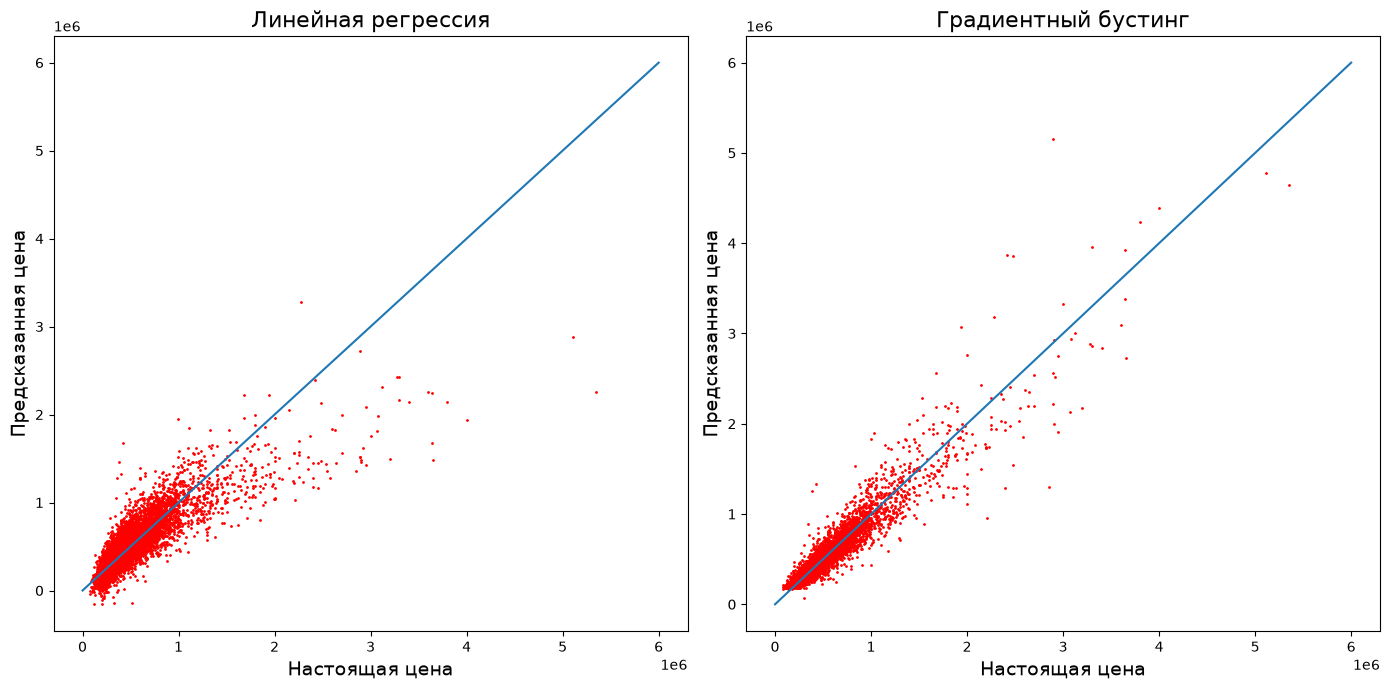

In [54]:
# Сравним визуально лучшую модель с линейной регрессией:
# по горизонтали — настоящая цена, по вертикали — предсказанная.
best_model = other_models["Градиентный бустинг (600 итераций, lr=0.05)"]
best_predictions = best_model.predict(test_points)

figure, axes = plt.subplots(1, 2, figsize=(14, 7))

for axis, predictions, title in [
    (axes[0], test_predictions_linear, "Линейная регрессия"),
    (axes[1], best_predictions, "Градиентный бустинг"),
]:
    axis.scatter(test_values, predictions, s=1, c='r')
    axis.plot([0, 6 * 10**6], [0, 6 * 10**6])
    axis.set_xlabel('Настоящая цена', fontsize=14)
    axis.set_ylabel('Предсказанная цена', fontsize=14)
    axis.set_title(title, fontsize=16)

plt.tight_layout()
plt.show()

### Отчёт по пункту 3

| Модель | MAE | RMSE |
|---|---|---|
| Градиентный бустинг (600 итераций, lr=0.05) | 67 800 | 121 249 |
| Градиентный бустинг (1000 итераций, 63 листа) | 66 913 | 121 416 |
| Градиентный бустинг (по умолчанию) | 68 805 | 122 327 |
| Случайный лес (подобранный) | 70 730 | 134 156 |
| Случайный лес (базовый) | 70 874 | 135 314 |
| ExtraTrees (300 деревьев) | 71 859 | 137 533 |
| Линейная регрессия | 126 853 | 201 883 |

Градиентный бустинг — лучшая модель. Относительно базового случайного леса:

* RMSE: 135 314 → 121 249, улучшение на 10.4%;
* MAE: 70 874 → 66 913, улучшение на 5.6%.

Для сравнения: подбор параметров самого леса дал меньше 1%. То есть смена
алгоритма оказалась на порядок эффективнее, чем настройка параметров.

Почему бустинг выигрывает. Случайный лес усредняет ответы независимых
деревьев — он борется с разбросом, но систематическую ошибку убрать не может:
если все деревья одинаково недооценивают дорогие дома, среднее тоже будет
недооценивать. Бустинг же строит деревья последовательно, и каждое следующее
обучается именно на остатках предыдущих, поэтому систематические ошибки
исправляются шаг за шагом.

Про параметры бустинга. `learning_rate` задаёт, какую долю от найденной
поправки применять на каждом шаге. Маленький шаг (0.05) требует больше
итераций, но даёт более точный результат — это классический компромисс
«медленно и аккуратно против быстро и грубо».

Линейная регрессия проигрывает почти вдвое (RMSE 201 883 против 121 249).
На графике видно почему: для дорогих домов её предсказания систематически
занижены, точки уходят вниз от диагонали. Зависимость цены от площади и района
нелинейная, а линейная модель по определению может провести только прямую.

Итог: лучшая ошибка — RMSE ≈ 121 000, то есть около 22% от средней цены
дома в выборке. Это разумный уровень: оставшаяся ошибка во многом объясняется
факторами, которых нет в данных (состояние ремонта, вид из окна, срочность
продажи).

## Пункт 5 задания. Интеграция модели с веб-сервисом

Пошаговый алгоритм на примере FastAPI (для Flask и Django шаги те же,
отличается синтаксис).

Шаг 1. Сохранить обученную модель в файл.
Модель обучается один раз, а веб-сервис должен уметь её просто загрузить:

```python
import joblib
joblib.dump(best_model, "house_price_model.joblib")
```

Если в обучении использовались преобразования признаков (масштабирование,
кодирование категорий), сохранять нужно весь `Pipeline` целиком. Иначе на
проде данные будут обработаны иначе, чем при обучении, и прогнозы окажутся
неверными.

Шаг 2. Зафиксировать версии библиотек в `requirements.txt`. Модель,
сохранённая в scikit-learn 1.5, может не загрузиться в версии 1.2.

Шаг 3. Описать схему входных данных через `pydantic` — он сам проверит
типы и вернёт понятную ошибку, если клиент прислал что-то не то:

```python
from pydantic import BaseModel, Field

class House(BaseModel):
    bedrooms: int = Field(alias="Спальни")
    living_area: float = Field(alias="Жилая площадь")
    realtor_grade: int = Field(alias="Оценка риелтора")
    latitude: float = Field(alias="Широта")
    longitude: float = Field(alias="Долгота")
    # ... остальные признаки
```

Шаг 4. Загрузить модель один раз при старте приложения, а не внутри
обработчика запроса: иначе файл будет читаться с диска на каждый запрос:

```python
from fastapi import FastAPI

app = FastAPI()
model = joblib.load("house_price_model.joblib")   # один раз при запуске
```

Шаг 5. Написать эндпоинт предсказания. Модель обучалась на `DataFrame`,
поэтому на вход подаём `DataFrame` с теми же именами столбцов и в том же
порядке:

```python
import pandas as pd

@app.post("/predict")
def predict(house: House):
    features = pd.DataFrame([house.model_dump(by_alias=True)])
    price = model.predict(features)[0]
    return {"predicted_price": float(price)}
```

Шаг 6. Добавить эндпоинт проверки работоспособности `/health` — он нужен
для мониторинга и балансировщика нагрузки.

Шаг 7. Запустить сервер:

```bash
uvicorn main:app --host 0.0.0.0 --port 8000
```

FastAPI сам сгенерирует интерактивную документацию на `/docs`.

Шаг 8. Упаковать в Docker, чтобы окружение на сервере совпадало с
окружением разработчика:

```dockerfile
FROM python:3.12-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]
```

Шаг 9. Логировать входные данные и прогнозы — чтобы отслеживать data
drift: со временем реальные объявления перестают быть похожими на обучающую
выборку (цены на недвижимость растут), и качество модели незаметно падает.
Для нашей задачи это особенно актуально: данные собраны за 2014-2015 годы.

Шаг 10. Настроить регулярное переобучение на свежих данных и хранить
версии моделей (например, в MLflow), чтобы можно было откатиться назад.